# Cosmological applications of FastNBessel

Every section below contains the actual `NBessel` or `NBesselND`
call for the corresponding application in the paper.  The input
tables use a transparent flat $\Lambda$CDM model with
$\Omega_m=0.315$, $\Omega_b=0.049$, $h=0.674$, $n_s=0.965$, and
$\sigma_8=0.811$.  The direct-quadrature calculations are included
only as independent checks; they are not part of FastNBessel.

Install the repository with `python -m pip install '.[examples]'`
before running the notebook from this `examples/` directory.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from nbessel import BinAverage, NBessel, NBesselND, log_zero_pad_nd
import generate_fiducial_inputs as fiducial
from quadrature import simpson_1d, simpson_2d_diagonal_interpolated

DATA = Path("data")
if not (DATA / "linear_matter_power.txt").exists():
    fiducial.main()

## Shared plotting helpers

The helpers below contain no FastNBessel calculations.  They load a
tabulated two-dimensional source, choose a diagonal output slice,
and draw the transform and its fractional difference
$\epsilon_{\mathrm{frac}}$.

In [2]:
def grid_table(name):
    table = np.loadtxt(DATA / name)
    return table[1:, 0], table[0, 1:], table[1:, 1:]


def indices_in_range(grid, lower, upper, count=128):
    available = np.flatnonzero((grid >= lower) & (grid <= upper))
    if available.size <= count:
        return available
    return np.unique(
        np.round(np.linspace(available[0], available[-1], count)).astype(int)
    )


def comparison_plot(x, fast, reference, xlabel, ylabel, title, transform_scale="auto"):
    with np.errstate(divide="ignore", invalid="ignore"):
        residual = np.where(reference != 0.0, (fast - reference) / reference, np.nan)
    figure, axes = plt.subplots(
        2, 1, figsize=(6.5, 5.5), sharex=True, layout="constrained",
        gridspec_kw={"height_ratios": [2.2, 1.0]},
    )
    axes[0].plot(x, reference, color="black", lw=2, label="quadrature")
    axes[0].plot(x, fast, "--", color="#d55e00", label="FastNBessel")
    axes[0].set_ylabel(ylabel)
    axes[0].set_title(title)
    axes[0].legend(frameon=False)
    if transform_scale == "linear":
        axes[0].margins(y=0.08)
    elif np.all(np.asarray(reference) > 0.0) and np.all(np.asarray(fast) > 0.0):
        axes[0].set_yscale("log")
    else:
        nonzero = np.abs(np.concatenate([reference, fast]))
        nonzero = nonzero[nonzero > 0.0]
        axes[0].set_yscale("symlog", linthresh=np.max(nonzero) * 1.0e-4)
        axes[0].axhline(0.0, color="0.75", lw=0.6)
    axes[1].plot(x, residual, color="#0072b2")
    axes[1].axhline(0.0, color="0.6", lw=0.7)
    axes[1].set_ylabel(r"$\epsilon_{\mathrm{frac}}$")
    axes[1].set_xlabel(xlabel)
    axes[1].set_xscale("log")
    axes[1].grid(alpha=0.2)
    plt.show()
    absolute = np.abs(residual[np.isfinite(residual)])
    return {
        "median |epsilon_frac|": float(np.median(absolute)),
        "95th percentile": float(np.quantile(absolute, 0.95)),
        "fraction below 1e-5": float(np.mean(absolute < 1.0e-5)),
    }

## Fiducial matter power spectrum

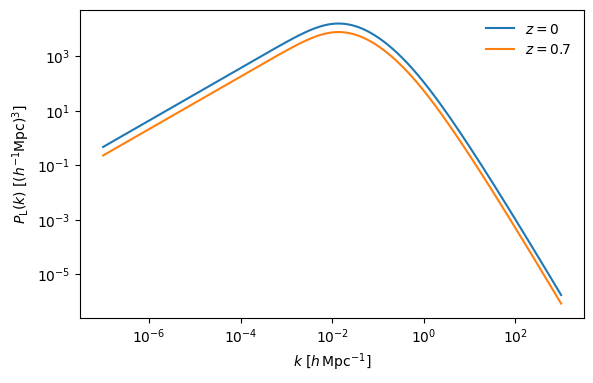

In [3]:
power = np.loadtxt(DATA / "linear_matter_power.txt")
plt.figure(figsize=(6.5, 4))
plt.loglog(power[:, 0], power[:, 1], label="$z=0$")
plt.loglog(power[:, 0], power[:, 2], label="$z=0.7$")
plt.xlabel(r"$k\ [h\,{\rm Mpc}^{-1}]$")
plt.ylabel(r"$P_{\rm L}(k)\ [(h^{-1}{\rm Mpc})^3]$")
plt.legend(frameon=False)
plt.show()

## Galaxy three-point correlation function

The bispectrum monopole is a two-dimensional input.  There is one
spherical Bessel function for each integration variable, so this is
the $(N_B,d)=(2,2)$ limit of the general interface.  The stored
input is undamped.  A distant endpoint window is applied only above
$20\,h\,{\rm Mpc}^{-1}$, followed by explicit zero padding; changing
these boundaries is a useful stability test.

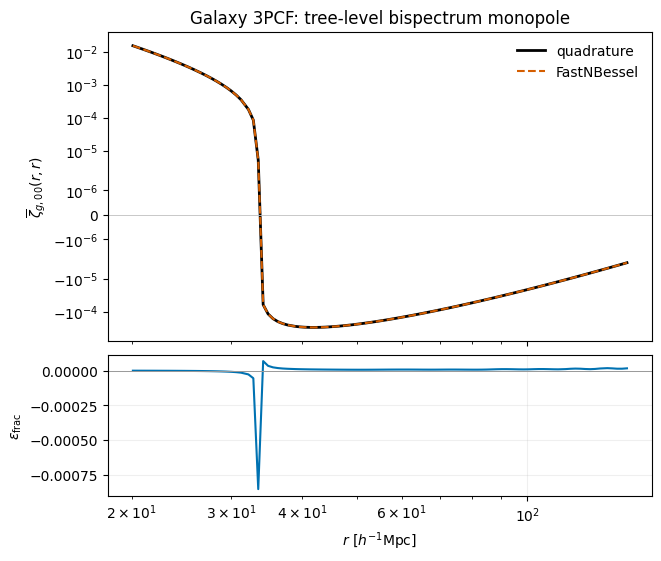

{'median |epsilon_frac|': 7.322242464439713e-06,
 '95th percentile': 2.425212035650798e-05,
 'fraction below 1e-5': 0.6770833333333334}

In [4]:
k1, k2, galaxy_source = grid_table("galaxy_bispectrum_multipole.txt")
endpoint1 = fiducial.endpoint_window(k1, 1e-5, 1e-4, 20.0, 50.0)
endpoint2 = fiducial.endpoint_window(k2, 1e-5, 1e-4, 20.0, 50.0)
galaxy_source = galaxy_source * endpoint1[:, None] * endpoint2[None, :]
radial_bin = BinAverage(0.95, 1.05, dimension=3)
(padded_k1, padded_k2), padded_galaxy_source = log_zero_pad_nd(
    [k1, k2], galaxy_source, 384
)
(r1, r2), galaxy_grid = NBesselND(
    [padded_k1, padded_k2], padded_galaxy_source
).spherical(
    [[0], [0]],
    biases=[1.0, 1.0],
    mellin_size=3,
    bins=[[radial_bin], [radial_bin]],
    y0=[0.2, 0.2],
)
galaxy_index = indices_in_range(r1, 20.0, 150.0, 96)
galaxy_fast = galaxy_grid[galaxy_index, galaxy_index]

galaxy_quad = simpson_2d_diagonal_interpolated(
    k1, k2, galaxy_source,
    r1[galaxy_index], r2[galaxy_index],
    [[0], [0]], [[1.0], [1.0]],
    bins=[[radial_bin], [radial_bin]], split=[0.2, 0.2],
)
comparison_plot(
    r1[galaxy_index], galaxy_fast, galaxy_quad,
    r"$r\ [h^{-1}{\rm Mpc}]$", r"$\overline{\zeta}_{g,00}(r,r)$",
    "Galaxy 3PCF: tree-level bispectrum monopole",
)

## Shear three-point correlation function

The shear example uses cylindrical Bessel functions.  Negative
integer orders are accepted and reduced using
$J_{-n}(x)=(-1)^nJ_n(x)$.  Here each angular separation is averaged
over a scale-invariant bin with edges $0.95\theta$ and $1.05\theta$.

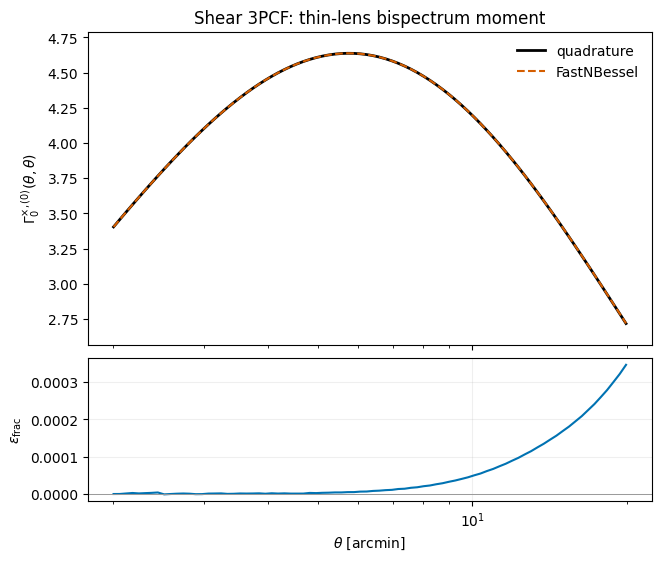

{'median |epsilon_frac|': 7.186930820144555e-06,
 '95th percentile': 0.0002589609545987723,
 'fraction below 1e-5': 0.524390243902439}

In [5]:
ell1, ell2, shear_source = grid_table("shear_bispectrum_multipole.txt")
angular_bin = BinAverage(0.95, 1.05, dimension=2)
(theta1, theta2), shear_grid = NBesselND([ell1, ell2], shear_source).cylindrical(
    [[-3], [-3]],
    biases=[0.0, 0.0],
    mellin_size=3,
    bins=[[angular_bin], [angular_bin]],
    y0=[1.0e-7, 1.0e-7],
)
theta_arcmin = theta1 * 180.0 * 60.0 / np.pi
shear_index = indices_in_range(theta_arcmin, 2.0, 20.0, 96)
shear_fast = shear_grid[shear_index, shear_index]

shear_quad = simpson_2d_diagonal_interpolated(
    ell1, ell2, shear_source,
    theta1[shear_index], theta2[shear_index],
    [[-3], [-3]], [[1.0], [1.0]],
    families=["cylindrical", "cylindrical"],
    bins=[[angular_bin], [angular_bin]], split=[100.0, 100.0],
)
comparison_plot(
    theta_arcmin[shear_index], shear_fast, shear_quad,
    r"$\theta\ [{\rm arcmin}]$", r"$\Gamma_0^{\times,(0)}(\theta,\theta)$",
    "Shear 3PCF: thin-lens bispectrum moment", transform_scale="linear",
)

## Anisotropic 3PCF covariance: $(N_B,d)=(4,2)$

Two spherical Bessel functions depend on each wavenumber.  The
nested `leg_biases` list gives the Mellin-contour split within each
integration variable.  The plotted transform contains the smooth
clustering term; constant shot-noise contact terms are not included.

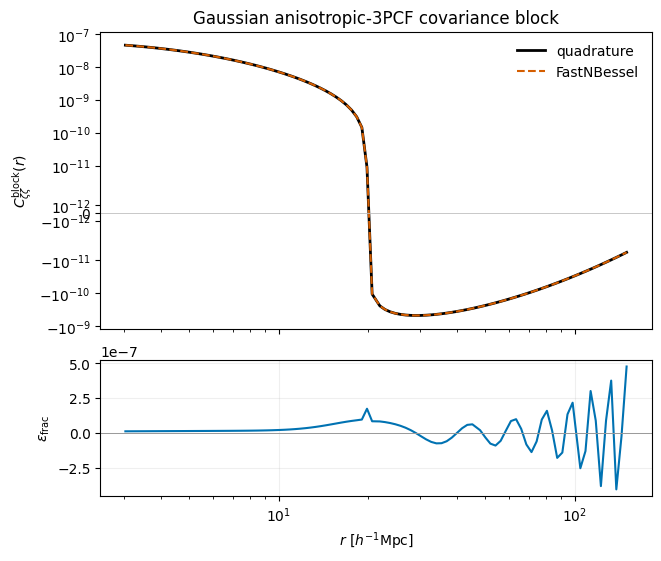

{'median |epsilon_frac|': 3.980304902181622e-08,
 '95th percentile': 2.638165601210597e-07,
 'fraction below 1e-5': 1.0}

In [6]:
k1, k2, covariance_source = grid_table("gaussian_3pcf_covariance_source.txt")
endpoint1 = fiducial.endpoint_window(k1, 1e-5, 1e-4, 20.0, 50.0)
endpoint2 = fiducial.endpoint_window(k2, 1e-5, 1e-4, 20.0, 50.0)
covariance_source = covariance_source * endpoint1[:, None] * endpoint2[None, :]
(padded_k1, padded_k2), padded_covariance_source = log_zero_pad_nd(
    [k1, k2], covariance_source, 192
)
covariance_orders = [[0, 2], [1, 1]]
covariance_ratios = [[1.0, 0.85], [1.0, 0.9]]
covariance_bin = BinAverage(0.95, 1.05, dimension=3)
covariance_bins = [[covariance_bin] * 2, [covariance_bin] * 2]
(r1, r2), covariance_grid = NBesselND(
    [padded_k1, padded_k2], padded_covariance_source
).spherical(
    covariance_orders,
    covariance_ratios,
    biases=[1.0, 1.0],
    leg_biases=[[0.5, 0.5], [0.5, 0.5]],
    mellin_size=65537,
    oversampling=4,
    bins=covariance_bins,
    y0=[0.2, 0.2],
)
covariance_index = indices_in_range(r1, 3.0, 150.0, 96)
covariance_fast = covariance_grid[covariance_index, covariance_index]

covariance_quad = simpson_2d_diagonal_interpolated(
    k1, k2, covariance_source,
    r1[covariance_index], r2[covariance_index],
    covariance_orders, covariance_ratios,
    bins=covariance_bins, split=[0.2, 0.2],
)
comparison_plot(
    r1[covariance_index], covariance_fast, covariance_quad,
    r"$r\ [h^{-1}{\rm Mpc}]$", r"$C_{\zeta\zeta}^{\rm block}(r)$",
    "Gaussian anisotropic-3PCF covariance block",
)

## Three-Bessel kernel for a general $N$-point covariance

All three Bessel functions share the same integration variable, so
this application uses the one-dimensional `NBessel` class.

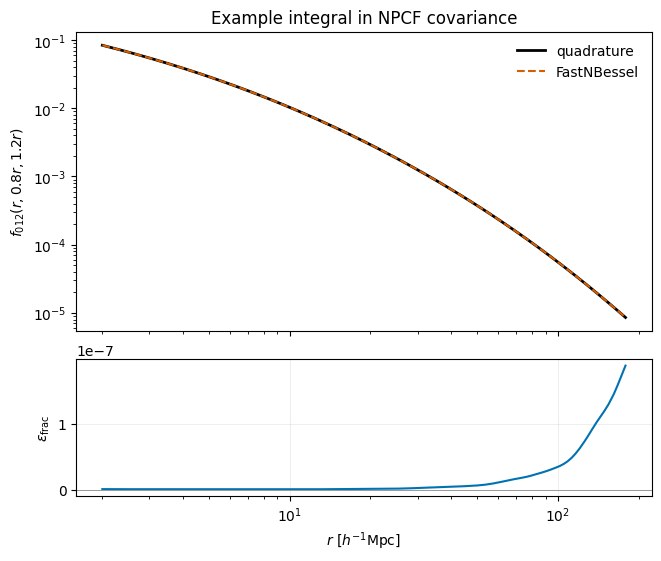

{'median |epsilon_frac|': 8.92568687886466e-10,
 '95th percentile': 1.0864912936801348e-07,
 'fraction below 1e-5': 1.0}

In [7]:
power_table = np.loadtxt(DATA / "linear_matter_power.txt")
k = power_table[:, 0]
npcf_source = power_table[:, 3] * fiducial.endpoint_window(
    k, 1e-7, 1e-6, 100.0, 1e3
)
npcf_ratios = [1.0, 0.8, 1.2]
r, npcf_all = NBessel(k, npcf_source).spherical(
    [0, 1, 2],
    npcf_ratios,
    bias=1.2,
    biases=[0.4] * 3,
    mellin_size=65537,
    oversampling=4,
    y0=0.2,
)
npcf_index = indices_in_range(r, 2.0, 180.0)
dense_k = np.geomspace(1.0e-7, 1.0e3, 131073)
npcf_quad = simpson_1d(
    dense_k, fiducial.npcf_transform_source(dense_k), r[npcf_index],
    [0, 1, 2], npcf_ratios,
)
comparison_plot(
    r[npcf_index], npcf_all[npcf_index], npcf_quad,
    r"$r\ [h^{-1}{\rm Mpc}]$", r"$f_{012}(r,0.8r,1.2r)$",
    "Example integral in NPCF covariance",
)

## Spherical Fourier--Bessel bispectrum

The radial source is transformed with three spherical Bessel
functions whose arguments are in the fixed ratio $1:0.8:1.2$.

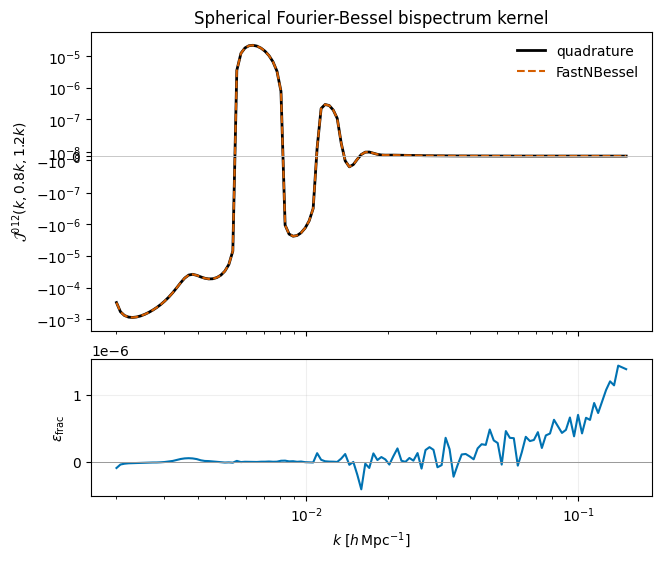

{'median |epsilon_frac|': 4.9308232528056143e-08,
 '95th percentile': 8.962779661242841e-07,
 'fraction below 1e-5': 1.0}

In [8]:
sfb_table = np.loadtxt(DATA / "sfb_radial_sources.txt")
radius, sfb_source = sfb_table[:, 0], sfb_table[:, 6]
sfb_ratios = [1.0, 0.8, 1.2]
k, sfb_all = NBessel(radius, sfb_source).spherical(
    [0, 1, 2],
    sfb_ratios,
    bias=2.0,
    biases=[2.0 / 3.0] * 3,
    mellin_size=65537,
    oversampling=4,
    y0=2.0e-4,
)
sfb_index = indices_in_range(k, 0.002, 0.15)
dense_radius = np.geomspace(0.1, 1.0e4, 32769)
sfb_quad = simpson_1d(
    dense_radius, fiducial.sfb_radial_inputs(dense_radius)[5],
    k[sfb_index], [0, 1, 2], sfb_ratios,
)
comparison_plot(
    k[sfb_index], sfb_all[sfb_index], sfb_quad,
    r"$k\ [h\,{\rm Mpc}^{-1}]$", r"${\cal J}^{012}(k,0.8k,1.2k)$",
    "Spherical Fourier-Bessel bispectrum kernel",
)

## SFB survey window with a second Bessel derivative

The density and redshift-space-distortion terms use the same
two-Bessel kernel.  The latter sets `derivatives=[0, 2]`, so the
second Bessel function is differentiated twice with respect to its
argument.

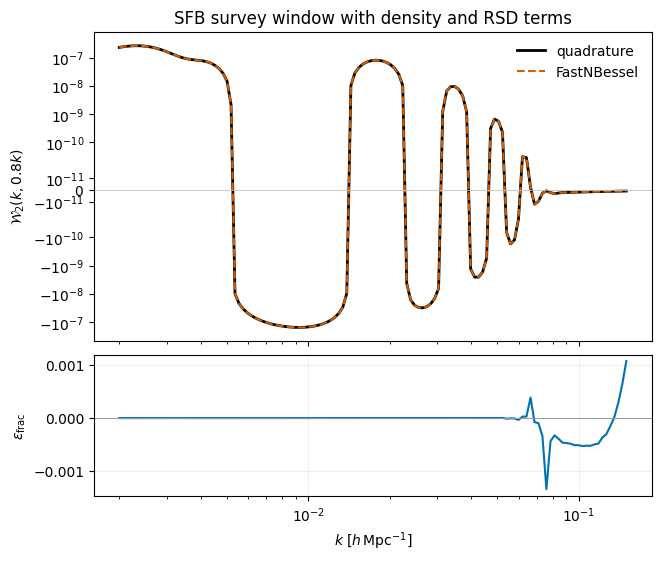

{'median |epsilon_frac|': 5.51202007653994e-09,
 '95th percentile': 0.0005092611401126938,
 'fraction below 1e-5': 0.7734375}

In [9]:
radius = sfb_table[:, 0]
density_source, rsd_source = sfb_table[:, 7], sfb_table[:, 8]
ratio = 0.8
transform_options = dict(
    bias=1.0,
    biases=[0.5, 0.5],
    mellin_size=65537,
    oversampling=4,
    y0=2.0e-4,
)
k, density_fast = NBessel(radius, density_source).spherical(
    [2, 2], [1.0, ratio], **transform_options
)
_, rsd_fast = NBessel(radius, rsd_source).spherical(
    [2, 2], [1.0, ratio], derivatives=[0, 2], **transform_options
)
window_index = indices_in_range(k, 0.002, 0.15)
prefactor = 2.0 * ratio * k[window_index] ** 2 / np.pi
window_fast = prefactor * (density_fast[window_index] + rsd_fast[window_index])

dense_radius = np.geomspace(0.1, 1.0e4, 32769)
dense_sfb = fiducial.sfb_radial_inputs(dense_radius)
density_quad = simpson_1d(
    dense_radius, dense_sfb[6], k[window_index], [2, 2], [1.0, ratio]
)
rsd_quad = simpson_1d(
    dense_radius, dense_sfb[7], k[window_index], [2, 2], [1.0, ratio],
    derivatives=[0, 2],
)
window_quad = prefactor * (density_quad + rsd_quad)
comparison_plot(
    k[window_index], window_fast, window_quad,
    r"$k\ [h\,{\rm Mpc}^{-1}]$", r"${\cal W}_2(k,0.8k)$",
    "SFB survey window with density and RSD terms",
)

## Repeated radial block in a two-loop calculation

This final example is another one-dimensional three-Bessel
transform, now with radial arguments in the ratio $1:0.75:1.25$.

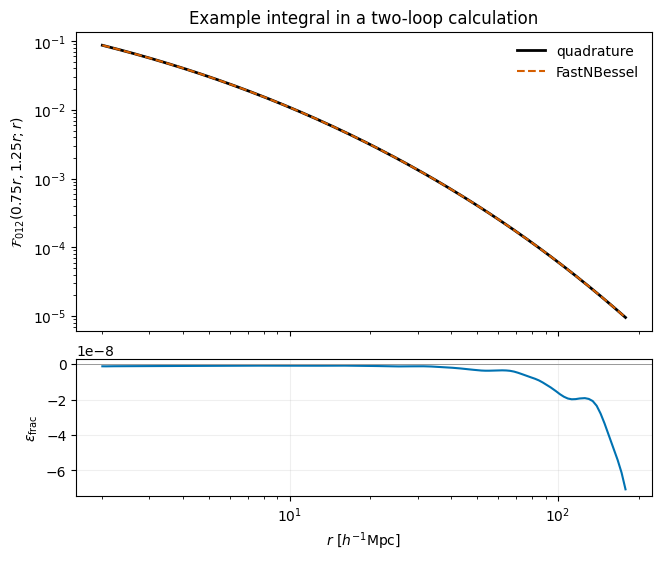

{'median |epsilon_frac|': 1.0655036719651707e-09,
 '95th percentile': 2.6303964405607607e-08,
 'fraction below 1e-5': 1.0}

In [10]:
loop_table = np.loadtxt(DATA / "two_loop_source.txt")
q, loop_source = loop_table[:, 0], loop_table[:, 2]
loop_source = loop_source * fiducial.endpoint_window(
    q, 1e-7, 1e-6, 100.0, 1e3
)
loop_ratios = [1.0, 0.75, 1.25]
r, loop_all = NBessel(q, loop_source).spherical(
    [0, 1, 2],
    loop_ratios,
    bias=1.2,
    biases=[0.4] * 3,
    mellin_size=65537,
    oversampling=4,
    y0=0.2,
)
loop_index = indices_in_range(r, 2.0, 180.0)
dense_q = np.geomspace(1.0e-7, 1.0e3, 131073)
loop_quad = simpson_1d(
    dense_q, fiducial.two_loop_transform_source(dense_q), r[loop_index],
    [0, 1, 2], loop_ratios,
)
comparison_plot(
    r[loop_index], loop_all[loop_index], loop_quad,
    r"$r\ [h^{-1}{\rm Mpc}]$", r"${\cal F}_{012}(0.75r,1.25r;r)$",
    "Example integral in a two-loop calculation",
)